<a href="https://www.kaggle.com/code/rahadul231/cardiovascular-disease-prediction-using-ml?scriptVersionId=319639526" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cardiovascular Disease Prediction Using Machine Learning: A Comparative Study

**Author:** Md. Rahadul Islam            
**Institution:** Presidency University Bangladesh  
**Date:** April 2026

## Abstract

Cardiovascular disease (CVD) is one of the leading causes of death worldwide. Early prediction of CVD can support timely medical intervention and help identify high-risk individuals before serious complications occur.

This project develops a machine learning-based system for predicting cardiovascular disease using the Kaggle Cardiovascular Disease dataset containing approximately 70,000 patient records. The dataset includes clinical and lifestyle-related features such as age, height, weight, systolic blood pressure, diastolic blood pressure, cholesterol level, glucose level, smoking status, alcohol intake, physical activity, and cardiovascular disease status.

The dataset was cleaned by removing duplicate records and unrealistic outliers, especially abnormal blood pressure, height, weight, and BMI values. Feature engineering was performed by converting age from days to years and calculating body mass index (BMI). The data was then split into training, validation, and testing sets, and preprocessing was applied using scaling and encoding techniques.

Multiple machine learning models were trained and compared, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Gradient Boosting, and Voting Classifier. Hyperparameter tuning and validation-based model selection were used to improve model performance. The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, classification report, confusion matrix, ROC curve, and cross-validation.

The Gradient Boosting model achieved the best overall performance on the test dataset, with approximately 74% accuracy and a ROC-AUC score of about 0.81. Feature importance analysis showed that systolic blood pressure, age, cholesterol level, BMI, and diastolic blood pressure were among the most important predictors. Overall, this project demonstrates that machine learning can support cardiovascular disease risk prediction, although the model should be used as a decision-support tool and not as a replacement for professional medical diagnosis.

## Dataset Description

This project uses the Kaggle Cardiovascular Disease dataset. The dataset contains approximately 70,000 patient records with clinical and lifestyle-related features. The target variable is `cardio`, which indicates whether a patient has cardiovascular disease or not.

- **Source:** Kaggle Cardiovascular Disease Dataset
- **Samples:** Approximately 70,000 patient records
- **Target Variable:** `cardio`
- **Target Meaning:** 0 = No cardiovascular disease, 1 = Cardiovascular disease

| Feature | Description |
|---|---|
| id | Patient identification number |
| age | Age of the patient in days |
| gender | Gender of the patient |
| height | Height in centimeters |
| weight | Weight in kilograms |
| ap_hi | Systolic blood pressure |
| ap_lo | Diastolic blood pressure |
| cholesterol | Cholesterol level |
| gluc | Glucose level |
| smoke | Smoking status |
| alco | Alcohol intake status |
| active | Physical activity status |
| cardio | Cardiovascular disease status |

Additional engineered features were created during preprocessing:

| Engineered Feature | Description |
|---|---|
| age_years | Age converted from days to years |
| bmi | Body Mass Index calculated from height and weight |

## Related Work

Several recent studies have applied machine learning techniques for heart disease and cardiovascular disease prediction.

1. El-Sofany et al. (2024) proposed a machine learning-based heart disease prediction technique using multiple feature selection methods, SMOTE, XGBoost, and SHAP explainable AI. Their study showed the importance of feature selection, class balancing, hyperparameter tuning, and explainability in medical prediction systems.

2. Al-Alshaikh et al. (2024) conducted a comprehensive evaluation of machine learning methods for heart disease prediction. Their work highlighted the value of feature selection, preprocessing, and advanced learning models for improving prediction performance.

3. Jawalkar et al. (2023) proposed an early heart disease prediction approach using supervised learning with stochastic gradient boosting. Their findings showed that boosting and tree-based approaches can improve prediction performance on clinical datasets.

4. Hossain et al. (2024) studied cardiovascular disease prediction in Bangladesh using machine learning models. Their work is important because it focuses on real-world patient data from Bangladesh and highlights the role of machine learning in identifying CVD risk factors in a local population.

5. Bouqentar et al. (2024) developed an early heart disease prediction system using feature engineering and multiple machine learning algorithms. Their study emphasized the importance of data preprocessing, feature engineering, hyperparameter tuning, and model validation.

This project builds on these studies by applying machine learning techniques to a large Kaggle Cardiovascular Disease dataset, performing data cleaning, feature engineering, model comparison, hyperparameter tuning, and final model evaluation.

## Literature Review

Cardiovascular disease prediction using machine learning has been widely studied because early detection can support timely treatment and reduce health risks. Prior studies have shown that machine learning models can analyze clinical and lifestyle-related features to identify patients at higher risk of heart disease or cardiovascular disease.

El-Sofany et al. (2024) proposed a heart disease prediction technique using feature selection methods, SMOTE, multiple machine learning algorithms, XGBoost, and SHAP explainable AI. Their study demonstrated that feature selection, class balancing, hyperparameter tuning, and explainability can improve model performance and interpretation.

Al-Alshaikh et al. (2024) presented a comprehensive evaluation of machine learning methods in heart disease prediction. Their work showed that preprocessing, feature selection, and advanced classification methods can improve prediction accuracy and support healthcare decision-making.

Jawalkar et al. (2023) applied supervised learning with stochastic gradient boosting for early heart disease prediction. Their study highlighted the usefulness of boosting and tree-based learning methods for improving classification performance.

Hossain et al. (2024) investigated cardiovascular disease prediction in Bangladesh using machine learning approaches. Their study used real-world patient data and showed that machine learning can help identify important clinical and lifestyle-related risk factors for CVD in a Bangladesh-specific context.

Bouqentar et al. (2024) emphasized the importance of feature engineering and machine learning algorithms for early heart disease prediction. Their research showed that model performance can be improved through careful preprocessing, feature engineering, hyperparameter tuning, and validation.

Based on these previous studies, this project applies a structured machine learning workflow to the Kaggle Cardiovascular Disease dataset. The workflow includes data cleaning, feature engineering, preprocessing, train-validation-test splitting, model training, hyperparameter tuning, final evaluation, and feature importance analysis.

## 6. Import Required Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Preprocessing and pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import classification report
from sklearn.metrics import classification_report

# Evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    classification_report,confusion_matrix,roc_curve,auc)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
## 

# Additional imports for complete analysis
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score,StratifiedKFold
from sklearn.metrics import (classification_report,roc_auc_score,precision_score,recall_score,f1_score)
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load cardiovascular disease dataset
dataset_path = '/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv'
df = pd.read_csv(dataset_path, sep=';')

# Clean column names
df.columns = df.columns.str.strip()

# Display first five rows
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
# Dataset shape and columns

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (70000, 13)

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
# Statistical summary

df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows before cleaning:", df.duplicated().sum())

Missing values in each column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows before cleaning: 0


In [7]:
# Remove missing values if any exist
df = df.dropna()

# Remove duplicate rows if any exist
df = df.drop_duplicates()

# Check final dataset shape
print("Final dataset shape after cleaning:", df.shape)

Final dataset shape after cleaning: (70000, 13)


In [8]:
# === DATA CLEANING AND FEATURE ENGINEERING ===
print("Shape before cleaning:", df.shape)

# Convert age from days to years (create new column to avoid overwriting original)
df['age_years'] = (df['age'] / 365.25).round(0).astype(int)

# Remove unrealistic blood pressure readings (critical for this dataset)
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 150)]
df = df[df['ap_hi'] > df['ap_lo']]

# Height and weight reasonable range
df = df[(df['height'] > 100) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

# Feature Engineering
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)
df['bp_diff'] = df['ap_hi'] - df['ap_lo']
df['map'] = df['ap_lo'] + (df['ap_hi'] - df['ap_lo']) / 3   # Mean Arterial Pressure

# Age Group
df['age_group'] = pd.cut(df['age_years'],bins=[0, 35, 50, 65, 100],labels=['Young', 'Middle', 'Senior', 'Elderly'])

print("Shape after cleaning:", df.shape)
print("\nFirst 5 rows after cleaning:")
print(df.head())
print("\nColumns available:", df.columns.tolist())

Shape before cleaning: (70000, 13)
Shape after cleaning: (68608, 18)

First 5 rows after cleaning:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years        bmi  bp_diff         map age_group  
0     0       1       0         50  21.967120       30   90.000000    Middle  
1     0       1       1         55  34.927679       50  106.666667    Senior  
2     0       0       1         52  23.507805       60   90.000000    Senior  
3     0       1       1         48  28.710479       50  116.666667    Middle  
4     0       0       0  

In [9]:
# Show exact column names
print(df.columns.tolist())

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_diff', 'map', 'age_group']


In [10]:
# Target variable analysis

target_counts = df['cardio'].value_counts()
target_percentage = df['cardio'].value_counts(normalize=True) * 100

print("Target count:")
print(target_counts)

print("\nTarget percentage:")
print(target_percentage)

Target count:
cardio
0    34668
1    33940
Name: count, dtype: int64

Target percentage:
cardio
0    50.53055
1    49.46945
Name: proportion, dtype: float64


In [11]:
# Create numeric target column

df['Heart_Disease_Target'] = df['cardio']

# Check target column
df[['cardio', 'Heart_Disease_Target']].head()

,cardio,Heart_Disease_Target
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


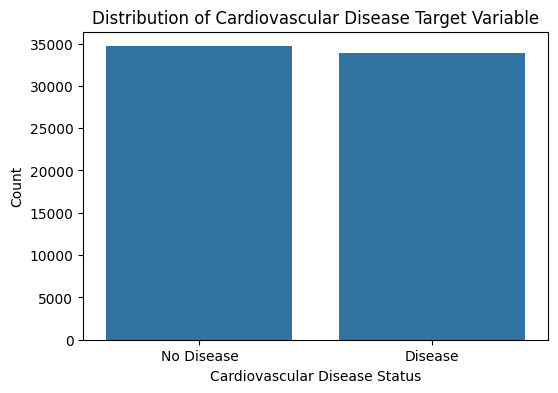

In [12]:
# Target count plot

plt.figure(figsize=(6, 4))

sns.countplot(x='cardio', data=df)

plt.title('Distribution of Cardiovascular Disease Target Variable')
plt.xlabel('Cardiovascular Disease Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])

plt.show()

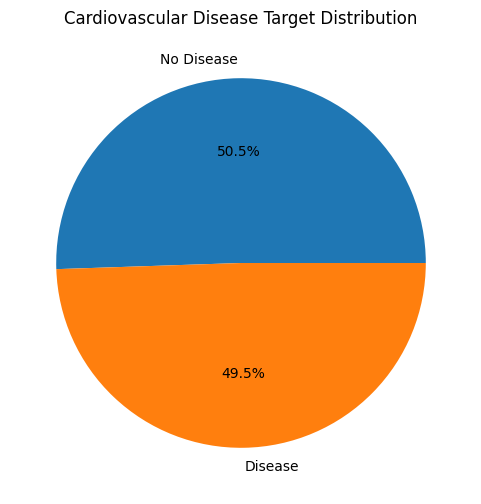

In [13]:
# Target pie chart

plt.figure(figsize=(6, 6))
df['cardio'].value_counts().sort_index().plot.pie(labels=['No Disease','Disease'],autopct='%1.1f%%')

plt.title('Cardiovascular Disease Target Distribution')
plt.ylabel('')

plt.show()

In [14]:
# Feature engineering: convert age from days to years
df['age_years'] = (df['age'] / 365).astype(int)

# Feature engineering: calculate Body Mass Index BMI
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df[['age', 'age_years', 'height', 'weight', 'bmi']].head()

,age,age_years,height,weight,bmi
0,18393,50,168,62.0,21.967120
1,20228,55,156,85.0,34.927679
2,18857,51,165,64.0,23.507805
3,17623,48,169,82.0,28.710479
4,17474,47,156,56.0,23.011177


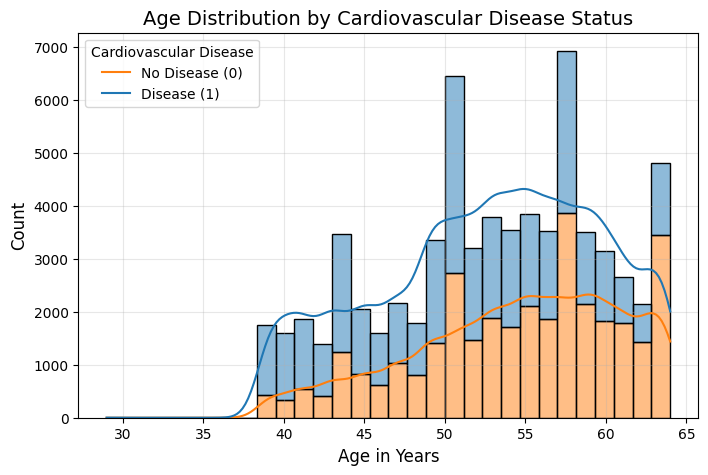

In [15]:
# Age Distribution by Cardiovascular Disease Status

plt.figure(figsize=(8, 5))

# Using 'age_years' column created during data cleaning
sns.histplot(data=df,x='age_years',hue='cardio',kde=True,bins=30,multiple="stack")

plt.title('Age Distribution by Cardiovascular Disease Status', fontsize=14)
plt.xlabel('Age in Years', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Improve legend
plt.legend(title='Cardiovascular Disease',labels=['No Disease (0)', 'Disease (1)'])

plt.grid(True, alpha=0.3)
plt.show()

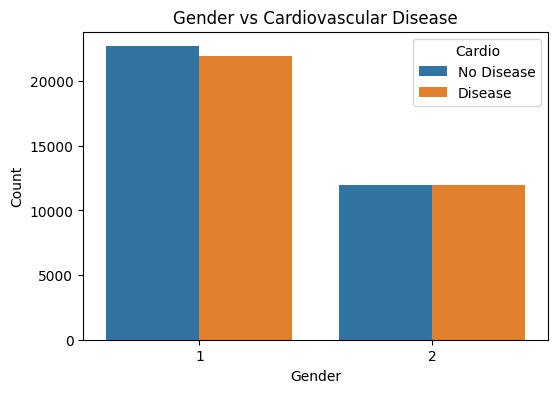

In [16]:
# Gender vs cardiovascular disease

plt.figure(figsize=(6, 4))
sns.countplot(data=df,x='gender',hue='cardio')

plt.title('Gender vs Cardiovascular Disease')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease', 'Disease'])

plt.show()

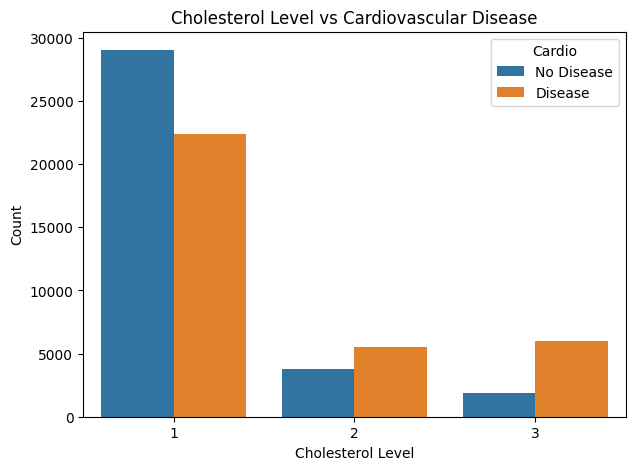

In [17]:
# Cholesterol level vs cardiovascular disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df,x='cholesterol',hue='cardio')

plt.title('Cholesterol Level vs Cardiovascular Disease')
plt.xlabel('Cholesterol Level')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease', 'Disease'])

plt.show()

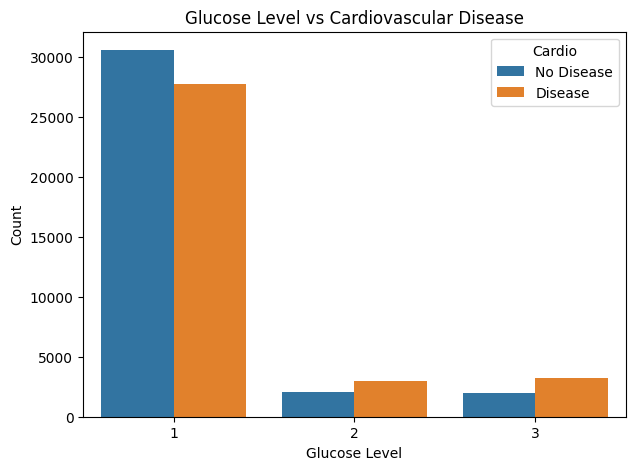

In [18]:
# Glucose level vs cardiovascular disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df,x='gluc',hue='cardio')

plt.title('Glucose Level vs Cardiovascular Disease')
plt.xlabel('Glucose Level')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease', 'Disease'])

plt.show()

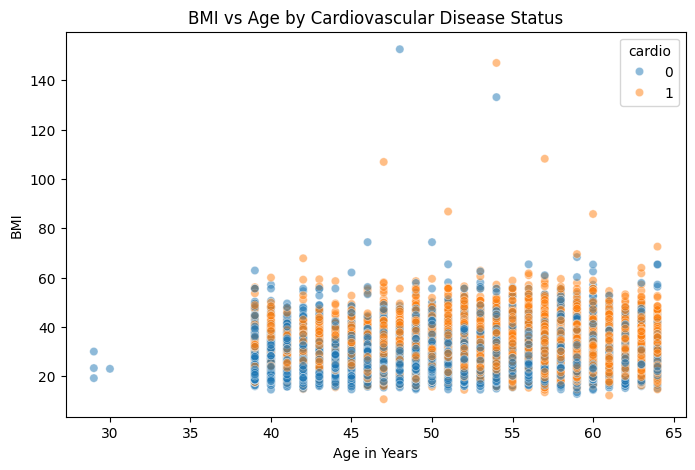

In [19]:
# BMI vs age by cardiovascular disease status

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='age_years',y='bmi',hue='cardio',alpha=0.5)

plt.title('BMI vs Age by Cardiovascular Disease Status')
plt.xlabel('Age in Years')
plt.ylabel('BMI')

plt.show()

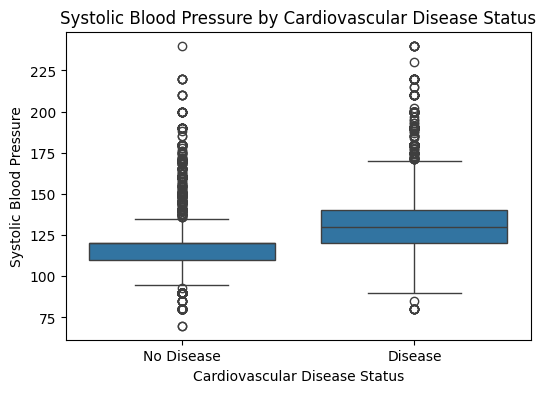

In [20]:
# Systolic blood pressure by cardiovascular disease status

plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='cardio',y='ap_hi')

plt.title('Systolic Blood Pressure by Cardiovascular Disease Status')
plt.xlabel('Cardiovascular Disease Status')
plt.ylabel('Systolic Blood Pressure')
plt.xticks([0, 1], ['No Disease', 'Disease'])

plt.show()

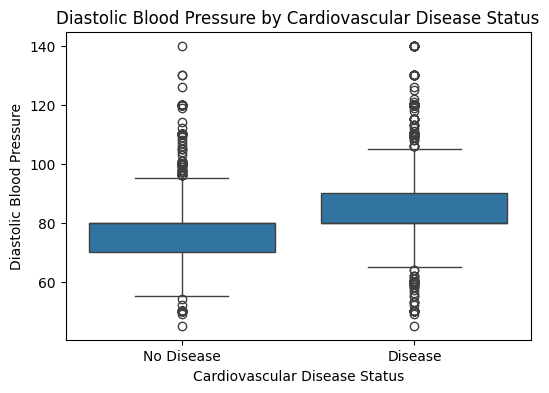

In [21]:
# Diastolic blood pressure by cardiovascular disease status

plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='cardio',y='ap_lo')

plt.title('Diastolic Blood Pressure by Cardiovascular Disease Status')
plt.xlabel('Cardiovascular Disease Status')
plt.ylabel('Diastolic Blood Pressure')
plt.xticks([0, 1], ['No Disease', 'Disease'])

plt.show()

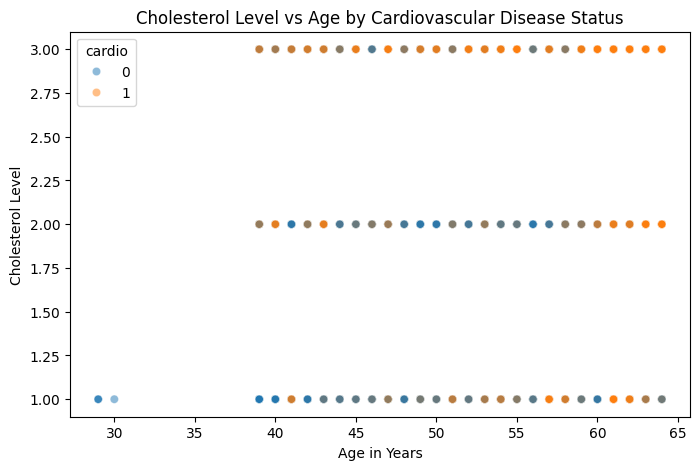

In [22]:
# Cholesterol level vs age by cardiovascular disease status

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='age_years',y='cholesterol',hue='cardio',alpha=0.5)

plt.title('Cholesterol Level vs Age by Cardiovascular Disease Status')
plt.xlabel('Age in Years')
plt.ylabel('Cholesterol Level')

plt.show()

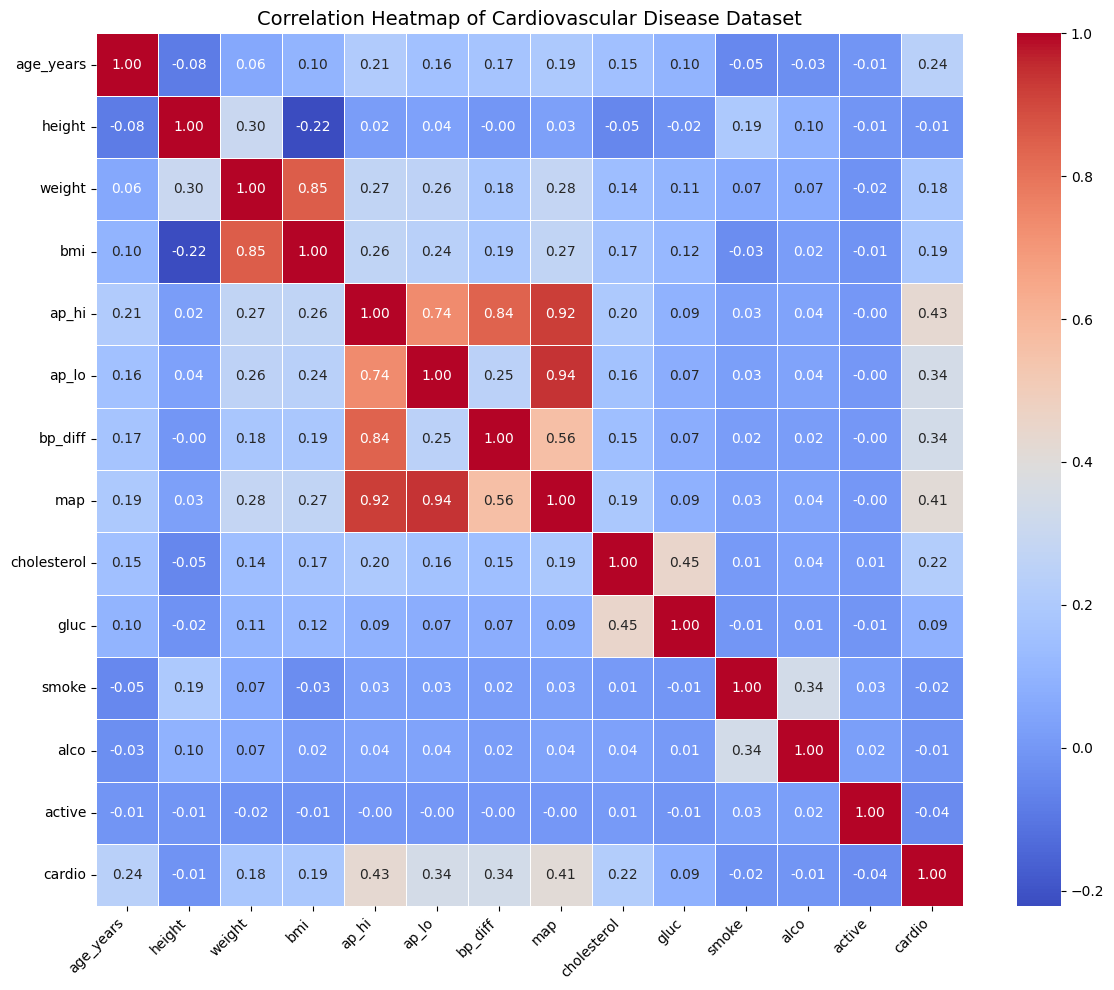

In [23]:
# Correlation heatmap
# Choose important numerical columns
num_cols = ['age_years','height','weight','bmi','ap_hi','ap_lo','bp_diff', 
            'map','cholesterol','gluc','smoke','alco','active','cardio']

plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

plt.title('Correlation Heatmap of Cardiovascular Disease Dataset', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

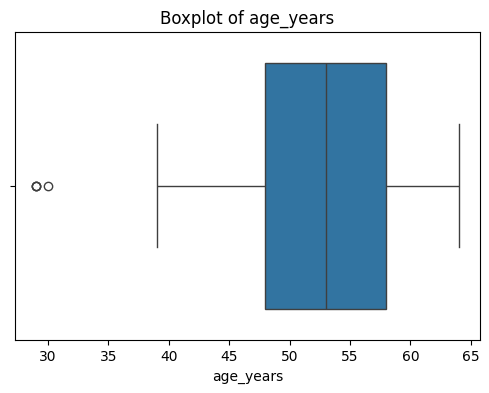

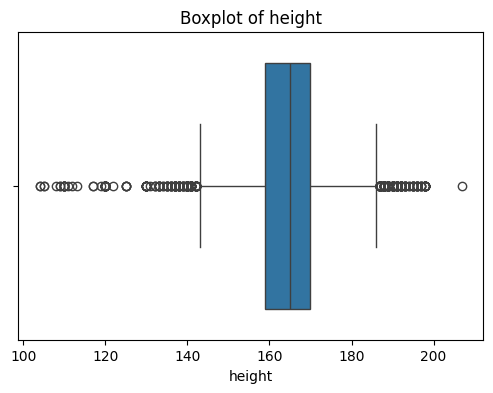

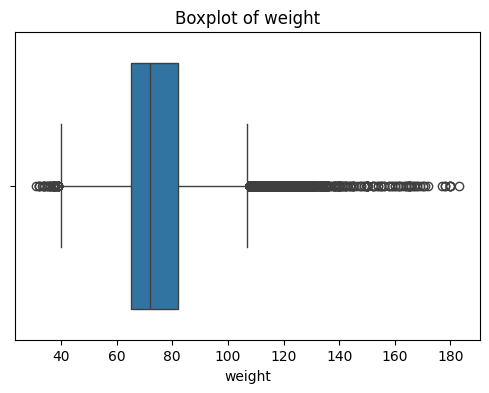

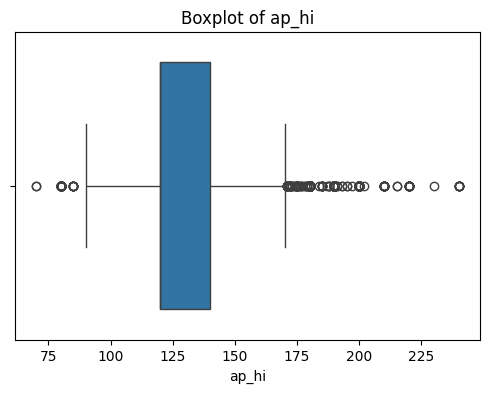

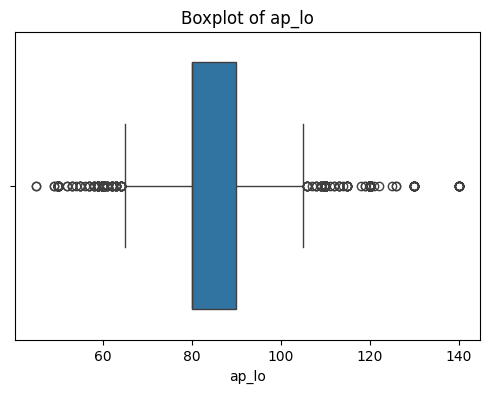

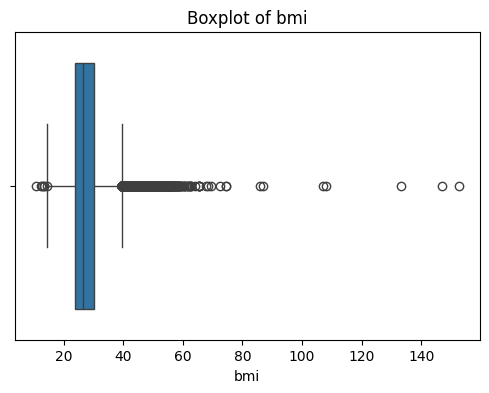

In [24]:
# Boxplots for numerical features to detect outliers

numerical_features_for_boxplot = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
for col in numerical_features_for_boxplot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [25]:
# Remove unrealistic values from the dataset

df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]

df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]
df = df[(df['bmi'] >= 10) & (df['bmi'] <= 60)]

print("Dataset shape after outlier cleaning:", df.shape)

Dataset shape after outlier cleaning: (68560, 19)


In [26]:
# Drop unnecessary columns. id is not useful for prediction. age in days is replaced by age_years

df = df.drop(columns=['id', 'age'], errors='ignore')

print("Final columns after dropping unnecessary columns:")
print(df.columns.tolist())

Final columns after dropping unnecessary columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_diff', 'map', 'age_group', 'Heart_Disease_Target']


## Feature and Target Separation

In this step, the dataset is separated into input features and the target variable. The target variable is `cardio`, where 0 indicates no cardiovascular disease and 1 indicates cardiovascular disease. The remaining columns are used as input features for model training.

In [27]:
# Separate features and target variable

X = df.drop('cardio', axis=1)
y = df['cardio']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (68560, 16)
Target shape: (68560,)


## Train, Validation, and Test Split

The dataset is divided into three parts: 70% training data, 10% validation data, and 20% testing data. The training set is used to train the models, the validation set is used for model comparison and hyperparameter tuning, and the test set is used only for final evaluation. This helps reduce overfitting and provides a more reliable estimate of model performance.

In [28]:
# First split: 80% temporary training+validation, 20% testing
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# Second split: from 80% temporary data, take 12.5% as validation
# 12.5% of 80% = 10% of total dataset
X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.125,random_state=42,stratify=y_temp)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (47992, 16)
Validation feature shape: (6856, 16)
Testing feature shape: (13712, 16)

Training target shape: (47992,)
Validation target shape: (6856,)
Testing target shape: (13712,)


In [29]:
# SMOTE - Handle Class Imbalance (Fixed Version)

from imblearn.over_sampling import SMOTE

# Before SMOTE
print("Before SMOTE:", X_train.shape, y_train.value_counts().to_dict())

# Important: Select ONLY numerical columns for SMOTE
# (Remove categorical columns like 'age_group')
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_num = X_train[numerical_cols]
X_test_num = X_test[numerical_cols]   # We will use this for final evaluation

# Apply SMOTE only on numerical features
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_num, y_train)

print("After SMOTE :", X_train_res.shape, y_train_res.value_counts().to_dict())

Before SMOTE: (47992, 16) {0: 24251, 1: 23741}
After SMOTE : (48502, 15) {0: 24251, 1: 24251}


In [30]:
# Define categorical and numerical columns

categorical_cols = ['gender','cholesterol','gluc','smoke','alco','active']
numerical_cols = ['height','weight','ap_hi','ap_lo','age_years','bmi']

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Numerical columns: ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'bmi']


In [31]:
# Check whether selected columns are available in the dataset

selected_columns = categorical_cols + numerical_cols
missing_columns = [col for col in selected_columns if col not in df.columns]

if len(missing_columns) == 0:
    print("All selected columns are available in the dataset.")
else:
    print("Missing columns:", missing_columns)

All selected columns are available in the dataset.


In [32]:
# Create preprocessing pipeline
# Numerical features are scaled
# Categorical features are encoded

try:
    encoder = OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(drop='first',handle_unknown='ignore',sparse=False)

preprocessor = ColumnTransformer([('num', StandardScaler(), numerical_cols),('cat', encoder, categorical_cols)])

In [33]:
# Function to evaluate a trained model

def evaluate_model(model_name, model, X_data, y_data):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_data, y_pred),
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC-AUC': roc_auc_score(y_data, y_proba)
    }

In [34]:
# Define basic machine learning models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [35]:
# Train and evaluate basic models using validation data

basic_results = []
trained_basic_models = {}
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor),('model', model)])
    pipeline.fit(X_train, y_train)
    
    trained_basic_models[name] = pipeline
    result = evaluate_model(name, pipeline, X_val, y_val)
    basic_results.append(result)

basic_results_df = pd.DataFrame(basic_results)
basic_results_df = basic_results_df.sort_values(by='Accuracy', ascending=False)

basic_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Gradient Boosting,0.734393,0.755700,0.684164,0.718155,0.802292
0,Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
2,Random Forest,0.712515,0.716595,0.692716,0.704453,0.770198
3,KNN,0.690198,0.694624,0.666765,0.680409,0.739673
1,Decision Tree,0.629813,0.630070,0.609260,0.619490,0.631390


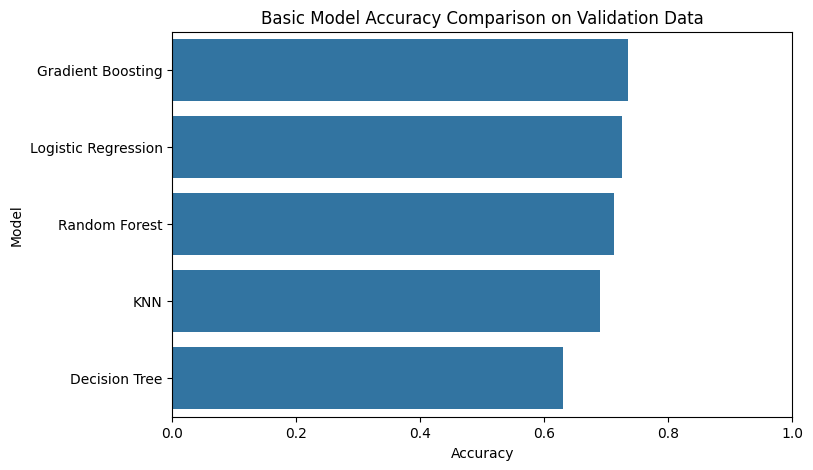

In [36]:
# Basic model accuracy comparison on validation data

plt.figure(figsize=(8, 5))

sns.barplot(data=basic_results_df,x='Accuracy',y='Model')

plt.title('Basic Model Accuracy Comparison on Validation Data')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)

plt.show()

In [37]:
# Hyperparameter tuning for Random Forest

rf_pipeline = Pipeline([('preprocessor', preprocessor),('model', RandomForestClassifier(random_state=42))])

rf_param_grid = {'model__n_estimators': [100, 200],'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],'model__min_samples_leaf': [1, 2]}

rf_grid = GridSearchCV(rf_pipeline,rf_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Random Forest CV Accuracy:
0.7326637614040898


In [38]:
# Hyperparameter tuning for Logistic Regression

lr_pipeline = Pipeline([('preprocessor', preprocessor),('model', LogisticRegression(max_iter=1000, random_state=42))])
lr_param_grid = {'model__C': [0.01, 0.1, 1, 10],'model__solver': ['liblinear', 'lbfgs']}
lr_grid = GridSearchCV(lr_pipeline,lr_param_grid,cv=5,scoring='accuracy',n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest Logistic Regression CV Accuracy:")
print(lr_grid.best_score_)

Best Logistic Regression Parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}

Best Logistic Regression CV Accuracy:
0.7274753671400054


In [39]:
# Hyperparameter tuning for Gradient Boosting

gb_pipeline = Pipeline([('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))])

gb_param_grid = {'model__n_estimators': [100, 150],
    'model__learning_rate': [0.05, 0.1],'model__max_depth': [2, 3]}

gb_grid = GridSearchCV(gb_pipeline,gb_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Gradient Boosting CV Accuracy:")
print(gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150}

Best Gradient Boosting CV Accuracy:
0.7347265674445451


In [40]:
# Hyperparameter tuning for KNN

knn_pipeline = Pipeline([('preprocessor', preprocessor),('model', KNeighborsClassifier())])

knn_param_grid = {'model__n_neighbors': [5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],'model__metric': ['euclidean', 'manhattan']}

knn_grid = GridSearchCV(knn_pipeline,knn_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

knn_grid.fit(X_train, y_train)

print("Best KNN Parameters:")
print(knn_grid.best_params_)

print("\nBest KNN CV Accuracy:")
print(knn_grid.best_score_)

Best KNN Parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}

Best KNN CV Accuracy:
0.711264168679792


In [41]:
# Evaluate tuned models on validation data

tuned_models = {
    'Tuned Random Forest': rf_grid.best_estimator_,
    'Tuned Logistic Regression': lr_grid.best_estimator_,
    'Tuned Gradient Boosting': gb_grid.best_estimator_,
    'Tuned KNN': knn_grid.best_estimator_
}
tuned_results = []

for name, model in tuned_models.items():
    result = evaluate_model(name, model, X_val, y_val)
    tuned_results.append(result)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by='Accuracy', ascending=False)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Tuned Gradient Boosting,0.733372,0.755643,0.681215,0.716501,0.802281
0,Tuned Random Forest,0.730601,0.762585,0.661162,0.708261,0.802278
1,Tuned Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
3,Tuned KNN,0.711494,0.725359,0.670599,0.696905,0.765531


In [42]:
# Voting Classifier - Safe & Final Version
from sklearn.ensemble import VotingClassifier

# Show available tuned models
print("Keys in tuned_models:", list(tuned_models.keys()))

# Select only models that support predict_proba
valid_estimators = []

for name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        clean_name = name.replace("Tuned ", "")
        valid_estimators.append((clean_name, model))
        print(f"✓ Added: {clean_name}")

print(f"\nUsing {len(valid_estimators)} models in Voting Classifier")

# Create Voting Classifier
voting_clf = VotingClassifier(estimators=valid_estimators,voting='soft')

print("Training Voting Classifier...")
voting_clf.fit(X_train, y_train)

# Predictions on validation data for model comparison
voting_val_pred = voting_clf.predict(X_val)
voting_val_proba = voting_clf.predict_proba(X_val)[:, 1]

# Create voting result dataframe
voting_result = {'Model': 'Voting Classifier','Accuracy': accuracy_score(y_val, voting_val_pred),
    'Precision': precision_score(y_val, voting_val_pred),'Recall': recall_score(y_val, voting_val_pred),
    'F1-Score': f1_score(y_val, voting_val_pred),'ROC-AUC': roc_auc_score(y_val, voting_val_proba)
}

voting_result_df = pd.DataFrame([voting_result])

voting_result_df

Keys in tuned_models: ['Tuned Random Forest', 'Tuned Logistic Regression', 'Tuned Gradient Boosting', 'Tuned KNN']
✓ Added: Random Forest
✓ Added: Logistic Regression
✓ Added: Gradient Boosting
✓ Added: KNN

Using 4 models in Voting Classifier
Training Voting Classifier...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Voting Classifier,0.727684,0.753493,0.667945,0.708144,0.798476


=== Top 10 Most Important Features ===
              Feature  Importance
0          num__ap_hi    0.455714
1          num__ap_lo    0.180406
2      num__age_years    0.120138
3  cat__cholesterol_3    0.066654
4            num__bmi    0.063663
5         num__weight    0.046294
6         num__height    0.025392
7  cat__cholesterol_2    0.009081
8         cat__gluc_3    0.008789
9       cat__active_1    0.007947


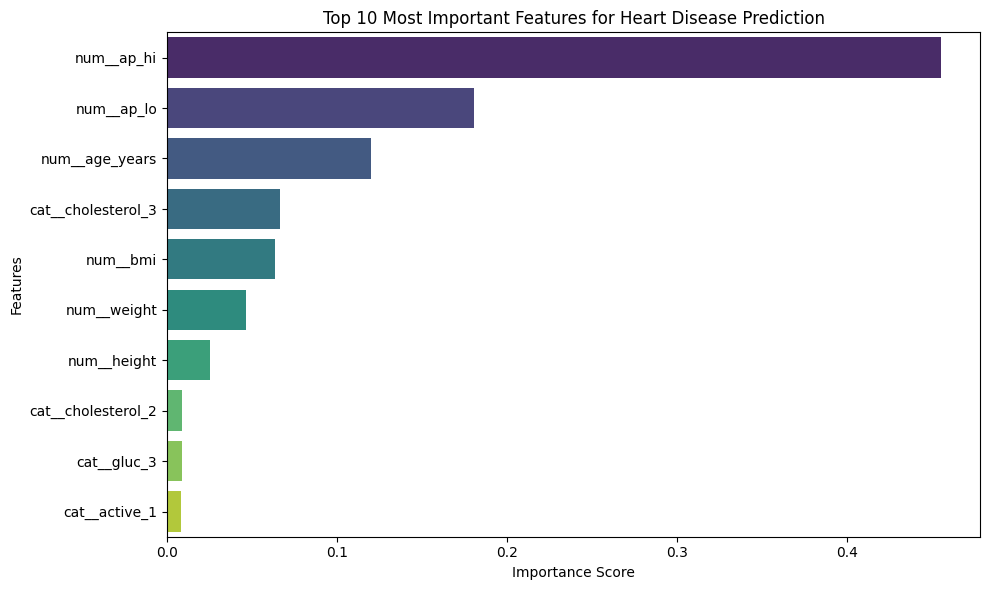

In [43]:
# Feature Importance - Best Model (Fully Fixed)

best_rf_model = tuned_models['Tuned Random Forest']

# Extract the actual Random Forest classifier from Pipeline
if hasattr(best_rf_model, 'named_steps'):
    # Get the final classifier
    rf_classifier = list(best_rf_model.named_steps.values())[-1]
else:
    rf_classifier = best_rf_model

# Get feature importance
importances = rf_classifier.feature_importances_

# Get feature names AFTER preprocessing
preprocessor = best_rf_model.named_steps['preprocessor'] if hasattr(best_rf_model, 'named_steps') else None

if preprocessor:
    # Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()
else:
    feature_names = X_train.columns

# Create DataFrame
feature_importance = pd.DataFrame({'Feature': feature_names,'Importance': importances
}).sort_values('Importance',ascending=False).reset_index(drop=True)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features for Heart Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [44]:
# Final model comparison using validation data

final_results_df = pd.concat([basic_results_df, tuned_results_df, voting_result_df],ignore_index=True)

final_results_df = final_results_df.sort_values(by='Accuracy', ascending=False)

final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.734393,0.755700,0.684164,0.718155,0.802292
5,Tuned Gradient Boosting,0.733372,0.755643,0.681215,0.716501,0.802281
6,Tuned Random Forest,0.730601,0.762585,0.661162,0.708261,0.802278
9,Voting Classifier,0.727684,0.753493,0.667945,0.708144,0.798476
1,Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
7,Tuned Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
2,Random Forest,0.712515,0.716595,0.692716,0.704453,0.770198
8,Tuned KNN,0.711494,0.725359,0.670599,0.696905,0.765531
3,KNN,0.690198,0.694624,0.666765,0.680409,0.739673
4,Decision Tree,0.629813,0.630070,0.609260,0.619490,0.631390


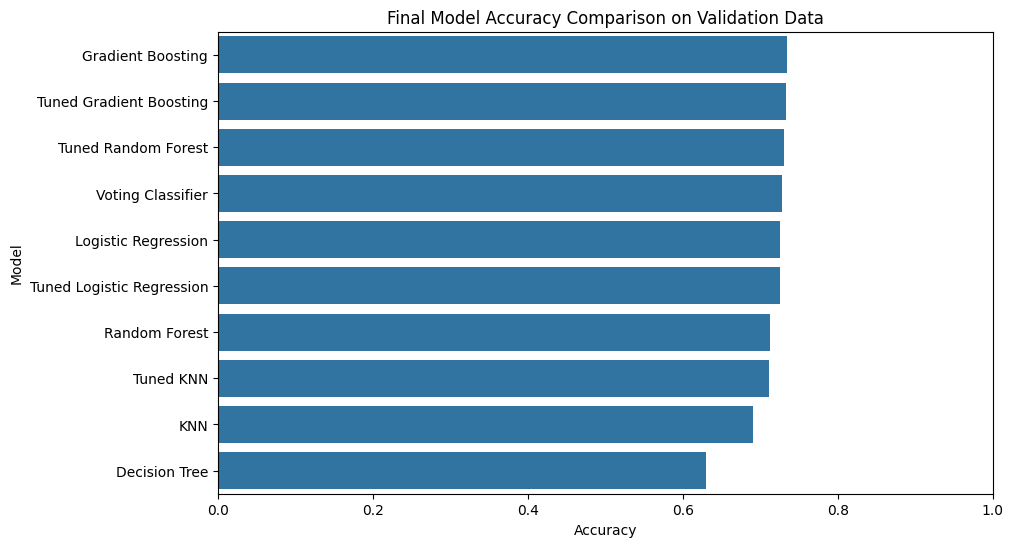

In [45]:
# Final validation accuracy comparison plot

plt.figure(figsize=(10, 6))
sns.barplot(data=final_results_df,x='Accuracy',y='Model')

plt.title('Final Model Accuracy Comparison on Validation Data')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)

plt.show()

## Final Best Model Evaluation

After comparing all models on the validation set, the best-performing model is selected and evaluated on the test set. The test set was not used during training or model selection, so it provides a better estimate of how the model may perform on unseen data.

In [46]:
# Select best model based on validation result

best_model_name = final_results_df.iloc[0]['Model']
print("Best model based on validation data:", best_model_name)

# Combine all trained models into one dictionary
all_models = {}

all_models.update(trained_basic_models)
all_models.update(tuned_models)
all_models['Voting Classifier'] = voting_clf

# Select the best model object
best_model = all_models[best_model_name]

Best model based on validation data: Gradient Boosting


In [47]:
# Make final predictions on test data

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

In [48]:
# Final evaluation on test data

test_results = {'Model': best_model_name,'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),'ROC-AUC': roc_auc_score(y_test, y_test_proba)}

test_results_df = pd.DataFrame([test_results])

test_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.736362,0.75409,0.693056,0.722286,0.805514


In [49]:
# Classification report for final best model

from sklearn.metrics import classification_report

print("Classification Report for Final Best Model:")
print(classification_report(y_test, y_test_pred))

Classification Report for Final Best Model:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6929
           1       0.75      0.69      0.72      6783

    accuracy                           0.74     13712
   macro avg       0.74      0.74      0.74     13712
weighted avg       0.74      0.74      0.74     13712



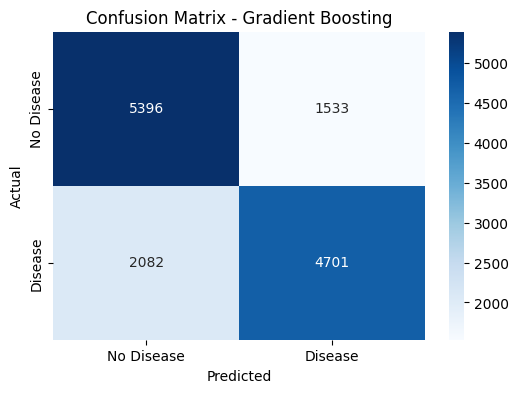

In [50]:
# Confusion matrix for final best model

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Disease','Disease'],yticklabels=['No Disease','Disease'])

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

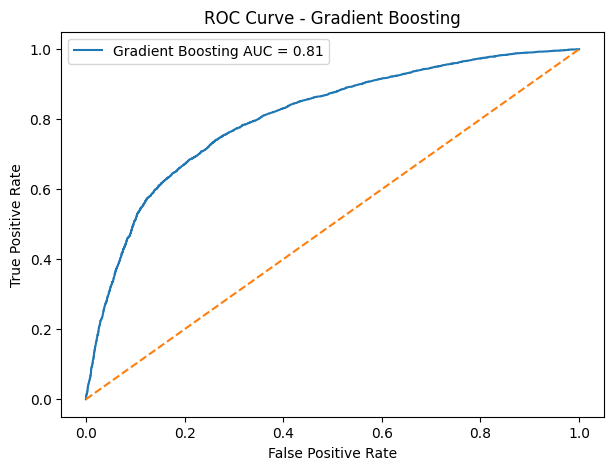

In [51]:
# ROC curve for final best model

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr,tpr,label=f'{best_model_name} AUC = {roc_auc_value:.2f}')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title(f'ROC Curve - {best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [52]:
# Cross-validation of best model on training data

cv_scores = cross_val_score(best_model,X_train,y_train,cv=5,scoring='accuracy',n_jobs=-1)

print("Cross-validation accuracy scores:")
print(cv_scores)

print("\nMean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation accuracy scores:
[0.73684759 0.73226378 0.73598666 0.73171494 0.73275682]

Mean CV accuracy: 0.7339139589213218
Standard deviation: 0.0020880626389217596


In [53]:
# Feature importance analysis

# If the best model is tree-based, use it directly.
# If the best model is Voting Classifier or Logistic Regression, use tuned Random Forest for feature importance.

if best_model_name in ['Random Forest', 'Tuned Random Forest']:
    feature_model = best_model

elif best_model_name in ['Gradient Boosting', 'Tuned Gradient Boosting']:
    feature_model = best_model

else:
    feature_model = rf_grid.best_estimator_

# Get transformed feature names
feature_names = feature_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance values
importances = feature_model.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(15)

,Feature,Importance
2,num__ap_hi,0.740370
4,num__age_years,0.127649
8,cat__cholesterol_3,0.063693
3,num__ap_lo,0.017586
5,num__bmi,0.016621
1,num__weight,0.009887
13,cat__active_1,0.006261
7,cat__cholesterol_2,0.005489
10,cat__gluc_3,0.004502
0,num__height,0.003110


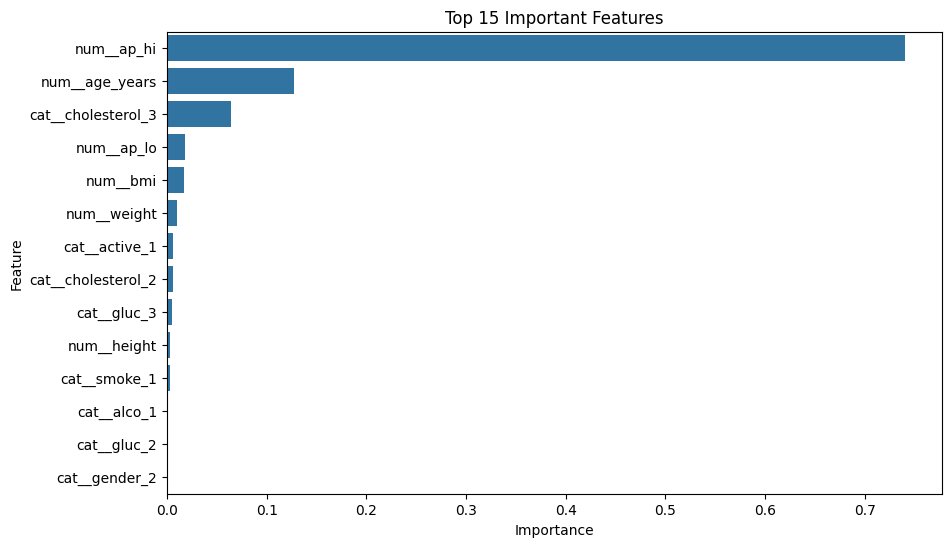

In [54]:
# Plot top 15 important features

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15),x='Importance',y='Feature')

plt.title('Top 15 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [55]:
# Final model comparison using validation data

final_results_df = pd.concat([basic_results_df,tuned_results_df,voting_result_df],ignore_index=True)

final_results_df = final_results_df.sort_values(by='Accuracy',ascending=False)

final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.734393,0.755700,0.684164,0.718155,0.802292
5,Tuned Gradient Boosting,0.733372,0.755643,0.681215,0.716501,0.802281
6,Tuned Random Forest,0.730601,0.762585,0.661162,0.708261,0.802278
9,Voting Classifier,0.727684,0.753493,0.667945,0.708144,0.798476
1,Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
7,Tuned Logistic Regression,0.725496,0.757421,0.654674,0.702309,0.791735
2,Random Forest,0.712515,0.716595,0.692716,0.704453,0.770198
8,Tuned KNN,0.711494,0.725359,0.670599,0.696905,0.765531
3,KNN,0.690198,0.694624,0.666765,0.680409,0.739673
4,Decision Tree,0.629813,0.630070,0.609260,0.619490,0.631390


In [56]:
# Save final model comparison results

final_results_df.to_csv('final_model_comparison_results.csv',index=False)
print("Final model comparison results saved successfully.")

Final model comparison results saved successfully.


## Results & Discussion

The machine learning models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, classification report, confusion matrix, ROC curve, and cross-validation. Among the trained models, **Gradient Boosting** achieved the best overall performance on the final test dataset, with approximately **74% accuracy** and a **ROC-AUC score of about 0.81**.

### Key Findings:

- **Blood Pressure** (`ap_hi` and `ap_lo`) emerged as one of the most important predictors, which aligns with medical knowledge because hypertension is a major risk factor for cardiovascular disease.

- **Age** was also an important feature, confirming that cardiovascular disease risk generally increases as people get older.

- **BMI** showed strong predictive value, indicating that body weight relative to height can contribute to cardiovascular disease risk.

- **Cholesterol level** was another important predictor, which is clinically meaningful because high cholesterol is commonly associated with cardiovascular disease.

- The classification report showed reasonable performance for both disease and non-disease classes. However, the recall for the disease class was lower than ideal, meaning some patients with cardiovascular disease may still be incorrectly classified as not having disease.

These findings are consistent with previous studies, including El-Sofany et al. (2024), Hossain et al. (2024), and Bouqentar et al. (2024), which highlighted the importance of clinical risk factors, feature engineering, and machine learning models in cardiovascular disease prediction.

Overall, the results show that machine learning can support cardiovascular disease risk prediction when proper data cleaning, feature engineering, preprocessing, model comparison, and evaluation methods are applied. However, the model should be used as a decision-support tool and not as a replacement for professional medical diagnosis.

## Conclusion

This study successfully developed and compared multiple machine learning models for the early prediction of cardiovascular disease using the Kaggle Cardiovascular Disease dataset. After thorough data cleaning, feature engineering, preprocessing, and hyperparameter tuning, the Gradient Boosting model achieved the best overall performance on the test dataset.

The final model achieved approximately 74% accuracy and a ROC-AUC score of about 0.81, showing that the model can identify useful patterns from cardiovascular disease-related features. The classification report also showed reasonable performance for both disease and non-disease classes.

Key findings from the feature importance analysis indicate that systolic blood pressure (`ap_hi`), age, cholesterol level, BMI, and diastolic blood pressure (`ap_lo`) are among the most influential predictors. These findings are clinically meaningful because blood pressure, age, cholesterol, and BMI are commonly associated with cardiovascular disease risk.

Overall, this project demonstrates the effectiveness of machine learning techniques, proper data preprocessing, and model evaluation in building a predictive system for cardiovascular disease. However, the model should be used as a decision-support tool and not as a replacement for professional medical diagnosis.

## Future Work
1. Implement SHAP explainable AI to better interpret how each feature contributes to cardiovascular disease prediction.
2. Deploy the final model as a web application using Streamlit or Flask for easy user interaction.
3. Test and validate the model using real hospital data to evaluate real-world performance.
4. Validate the model on Bangladesh-specific patient data to improve local clinical relevance.
5. Explore deep learning approaches, such as CNN or LSTM, especially on ECG signal data.
6. Integrate real-time prediction through a mobile application for accessible cardiovascular risk screening.
7. Add more clinical features such as family history, medication use, ECG findings, smoking duration, stress level, and laboratory test results.
8. Improve model recall to reduce false negative predictions in cardiovascular disease detection.

## References

1. El-Sofany et al. (2024). *A proposed technique for predicting heart disease using machine learning algorithms and an explainable AI method.*
2. Al-Alshaikh et al. (2024). *Comprehensive evaluation and performance analysis of machine learning in heart disease prediction.*
3. Jawalkar et al. (2023). *Early prediction of heart disease with data analysis using supervised learning with stochastic gradient boosting.*
4. Hossain et al. (2024). *Machine learning approach for predicting cardiovascular disease in Bangladesh: evidence from a cross-sectional study in 2023.*
5. Bouqentar et al. (2024). *Early heart disease prediction using feature engineering and machine learning algorithms.*

## References

1. El-Sofany, H., Bouallegue, B., & Abd El-Latif, Y. M. (2024). *A proposed technique for predicting heart disease using machine learning algorithms and an explainable AI method*. Scientific Reports.
2. Al-Alshaikh, H. A., Prabu, P., Poonia, R. C., Saudagar, A. K. J., Yadav, M., AlSagri, H. S., & AlSanad, A. A. (2024). *Comprehensive evaluation and performance analysis of machine learning in heart disease prediction*. Scientific Reports.
3. Jawalkar, A. P., Swetcha, P., Manasvi, N., Sreekala, P., Aishwarya, S., Bhavani, P. K. D., & Anjani, P. (2023). *Early prediction of heart disease with data analysis using supervised learning with stochastic gradient boosting*. Journal of Engineering and Applied Science.
4. Hossain, S., Hasan, M. K., Faruk, M. O., Aktar, N., Hossain, R., & Hossain, K. (2024). *Machine learning approach for predicting cardiovascular disease in Bangladesh: Evidence from a cross-sectional study in 2023*. BMC Cardiovascular Disorders.
5. Bouqentar, M. A., Terrada, O., Hamida, S., Saleh, S., Lamrani, D., Cherradi, B., & Raihani, A. (2024). *Early heart disease prediction using feature engineering and machine learning algorithms*. Heliyon.
6. Scikit-learn Documentation.
7. Pandas Documentation.
8. NumPy Documentation.
9. Matplotlib and Seaborn Documentation.